# MaIA Scoliosis Dataset — Data Exploration

**Sandbox tier.** Driven by `context/kits/cavekit-dataset-audit.md`.

Three phases, top-to-bottom:

1. **Descriptive profile** (R1) — visualize raw dataset properties.
2. **Inconsistency audit** (R2) — detect 18 issue codes, write `known_issues.csv`.
3. **Clean manifest** (R3) — produce `clean_index.csv` with `ok / warn / excluded` status.

Hard scope: target vertebrae are IDs 6–22 (T1–T12 + L1–L5, 17 classes). Cervical (1–5) and auxiliary (23–35) are intentionally ignored. Outputs land in `data/processed/audit/`.

## 0. Setup & Configuration

In [146]:
import hashlib
import json
import os
import random
from collections import Counter
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from PIL import Image


In [147]:
# ── Repo root discovery ──────────────────────────────────────────────────────
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "params.yaml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "params.yaml").exists():
    raise FileNotFoundError("Could not locate repo root (no params.yaml found above CWD).")

# ── Paths ────────────────────────────────────────────────────────────────────
DATASET_ROOT     = REPO_ROOT / "data" / "raw" / "MaIA_Scoliosis_Dataset"
AUDIT_OUT_DIR    = REPO_ROOT / "data" / "processed" / "audit"
INDEX_CSV        = DATASET_ROOT / "dataset_index.csv"
LABELS_DICT_JSON = DATASET_ROOT / "labels_dictionary.json"
METRICS_JSON_DIR = DATASET_ROOT / "RadiographMetrics" / "metrics_json"
CURVES_CSV_DIR   = DATASET_ROOT / "RadiographMetrics" / "curves_csv"
KNOWN_ISSUES_CSV = AUDIT_OUT_DIR / "known_issues.csv"
CLEAN_INDEX_CSV  = AUDIT_OUT_DIR / "clean_index.csv"
AUDIT_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Seed (single source of truth = params.yaml) ──────────────────────────────
with open(REPO_ROOT / "params.yaml") as f:
    SEED = int(yaml.safe_load(f)["data"]["random_seed"])
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# ── Vertebra ID ranges (cavekit-dataset-audit.md scope) ──────────────────────
TARGET_VERTEBRA_IDS: tuple[int, ...] = tuple(range(6, 23))   # T1..L5 (17 classes)
ALL_VERTEBRA_IDS:    tuple[int, ...] = tuple(range(1, 36))   # full raw label space
TARGET_COVERAGE_FULL = len(TARGET_VERTEBRA_IDS)              # 17

# ── Severity buckets (Cobb degrees) ──────────────────────────────────────────
SEVERITY_BUCKETS: tuple[tuple[str, float, float], ...] = (
    ("normal",    0.0,  10.0),
    ("mild",     10.0,  25.0),
    ("moderate", 25.0,  40.0),
    ("severe",   40.0, 999.0),
)

# ── Audit rule tables (R2 / R3) ──────────────────────────────────────────────
EXPECTED_ISSUE_CODES: tuple[str, ...] = (
    "missing_pair_binary_mask", "missing_pair_multi_mask", "missing_pair_metrics", "missing_pair_curve",
    "corrupt_file", "index_mismatch", "category_mislabeled", "duplicate_patient_id",
    "dim_mismatch", "resolution_outlier", "channel_inconsistency",
    "id_out_of_range", "target_coverage_low", "empty_mask",
    "cobb_angle_outlier", "missing_metadata_scoliosis", "curve_invalid", "csvl_apex_out_of_range",
)
# Warn-severity codes — a case carrying any of these (and no excluded trigger)
# is demoted to status="warn". target_coverage_low is included for consistency
# with the detector; the actual partial-coverage threshold is driven by
# target_vertebrae_count in build_clean_index.
WARN_TRIGGER_CODES = frozenset({
    "cobb_angle_outlier", "channel_inconsistency", "resolution_outlier",
    "missing_metadata_scoliosis", "curve_invalid", "csvl_apex_out_of_range",
    "missing_pair_metrics", "missing_pair_curve", "target_coverage_low",
})
# Fatal-severity codes — presence of any excludes the case entirely.
EXCLUDE_TRIGGER_CODES = frozenset({
    "corrupt_file", "missing_pair_binary_mask", "missing_pair_multi_mask",
    "dim_mismatch", "category_mislabeled", "duplicate_patient_id", "empty_mask",
    "index_mismatch",
})

print(f"REPO_ROOT     = {REPO_ROOT}")
print(f"DATASET_ROOT  = {DATASET_ROOT}")
print(f"AUDIT_OUT_DIR = {AUDIT_OUT_DIR}")
print(f"SEED          = {SEED}")
print(f"TARGET IDs    = {TARGET_VERTEBRA_IDS} (count={TARGET_COVERAGE_FULL})")


REPO_ROOT     = /home/ortiz/scoliosis
DATASET_ROOT  = /home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_Dataset
AUDIT_OUT_DIR = /home/ortiz/scoliosis/data/processed/audit
SEED          = 42
TARGET IDs    = (6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22) (count=17)


## 1. Dataset Index & Loaders

**Task T-001.** Reusable helpers consumed by every downstream profile / audit cell. Read `dataset_index.csv` once, resolve all label / metric / curve paths, expose lightweight readers for masks, metrics JSONs, and curve CSVs.

In [148]:
# ── 1.1 Vertebra ID → name lookup (limited to target IDs 6..22) ────────────────
with open(LABELS_DICT_JSON) as f:
    _labels_dict = json.load(f)
_id_name_raw: dict[int, str] = {
    int(k): v for k, v in _labels_dict["multiclass_id_png"].items()
}
VERTEBRA_NAME_BY_ID: dict[int, str] = {
    vid: _id_name_raw[vid] for vid in TARGET_VERTEBRA_IDS
}
ALL_VERTEBRA_NAME_BY_ID: dict[int, str] = {
    vid: _id_name_raw.get(vid, f"id_{vid}") for vid in ALL_VERTEBRA_IDS
}
print("Target vertebra names (IDs 6..22):")
for vid in TARGET_VERTEBRA_IDS:
    print(f"  {vid:>2d} → {VERTEBRA_NAME_BY_ID[vid]}")

Target vertebra names (IDs 6..22):
   6 → T1
   7 → T2
   8 → T3
   9 → T4
  10 → T5
  11 → T6
  12 → T7
  13 → T8
  14 → T9
  15 → T10
  16 → T11
  17 → T12
  18 → L1
  19 → L2
  20 → L3
  21 → L4
  22 → L5


In [149]:
# ── 1.2 Load dataset index and resolve absolute paths ─────────────────────────
if not INDEX_CSV.exists():
    raise FileNotFoundError(
        f"Missing dataset index: {INDEX_CSV}. Run `dvc pull data/raw` first."
    )

_index_raw = pd.read_csv(INDEX_CSV)

def _resolve(rel: str | float | None) -> str | None:
    if rel is None or (isinstance(rel, float) and pd.isna(rel)) or rel == "":
        return None
    return str(DATASET_ROOT / rel)

def _case_id_from_image(image: str) -> tuple[str, str] | None:
    """Return (prefix, numeric_id) from an image filename like 'S_42.jpg' or 'N_3.jpg'."""
    stem = Path(image).stem
    parts = stem.split("_", 1)
    if len(parts) != 2:
        return None
    return parts[0], parts[1]

def _metrics_path_for(image: str, category: str) -> str | None:
    """Build metrics_{id}.json path. Only Scoliosis cases have RadiographMetrics."""
    if category != "Scoliosis":
        return None
    parsed = _case_id_from_image(image)
    if parsed is None:
        return None
    p = METRICS_JSON_DIR / f"metrics_{parsed[1]}.json"
    return str(p) if p.exists() else None

def _curve_path_for(image: str, category: str) -> str | None:
    if category != "Scoliosis":
        return None
    parsed = _case_id_from_image(image)
    if parsed is None:
        return None
    p = CURVES_CSV_DIR / f"curve_{parsed[1]}.csv"
    return str(p) if p.exists() else None

INDEX = _index_raw.copy()
INDEX = INDEX.rename(columns={"split": "category"})
INDEX["category"] = INDEX["category"].astype("string")
INDEX["image"] = INDEX["image"].astype("string")
INDEX["patient_id"] = INDEX["patient_id"].astype("Int64")

INDEX["image_abs"]          = INDEX["radiograph_path"].map(_resolve)
INDEX["binary_mask_abs"]    = INDEX["label_binary_path"].map(_resolve)
INDEX["multi_mask_abs"]     = INDEX["multiclass_id_png"].map(_resolve)
INDEX["multi_gray_abs"]     = INDEX["multiclass_gray_jpg"].map(_resolve)
INDEX["multi_color_abs"]    = INDEX["multiclass_color_jpg"].map(_resolve)
INDEX["metrics_json_abs"]   = INDEX.apply(
    lambda r: _metrics_path_for(r["image"], r["category"]), axis=1
)
INDEX["curve_csv_abs"]      = INDEX.apply(
    lambda r: _curve_path_for(r["image"], r["category"]), axis=1
)

INDEX = INDEX.sort_values(["category", "patient_id"], kind="mergesort").reset_index(drop=True)
print(f"Loaded dataset index: {len(INDEX)} rows from {INDEX_CSV.name}")
INDEX.head(3)


Loaded dataset index: 250 rows from dataset_index.csv


,category,image,patient_id,radiograph_path,label_binary_path,multiclass_id_png,multiclass_gray_jpg,multiclass_color_jpg,metrics_json,image_abs,binary_mask_abs,multi_mask_abs,multi_gray_abs,multi_color_abs,metrics_json_abs,curve_csv_abs
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,None,None
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,None,None
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,None,None


In [150]:
# ── 1.3 Lightweight readers (lazy — no caching, no hidden state) ──────────────
def read_image(path: str | Path) -> np.ndarray:
    """Read a radiograph or mask image into an HxW or HxWxC numpy array."""
    return np.array(Image.open(path))

def read_image_meta(path: str | Path) -> tuple[int, int, str]:
    """Return (height, width, mode) without loading pixels into memory beyond PIL."""
    with Image.open(path) as im:
        w, h = im.size
        mode = im.mode
    return h, w, mode

def read_multi_mask(path: str | Path) -> np.ndarray:
    """Read a multiclass ID PNG and return a 2D uint8 array of pixel IDs."""
    arr = np.array(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr.astype(np.uint8)

def read_metrics_json(path: str | Path) -> dict:
    with open(path) as f:
        return json.load(f)

def read_curve_csv(path: str | Path) -> pd.DataFrame:
    return pd.read_csv(path)

def file_size_kb(path: str | Path | None) -> float:
    if path is None:
        return float("nan")
    p = Path(path)
    if not p.exists():
        return float("nan")
    return p.stat().st_size / 1024.0

def target_ids_present(multi_mask: np.ndarray) -> set[int]:
    """Set of target vertebra IDs (6..22) present in a multiclass mask."""
    present = set(int(v) for v in np.unique(multi_mask).tolist())
    return present & set(TARGET_VERTEBRA_IDS)

def all_ids_present(multi_mask: np.ndarray) -> set[int]:
    """Set of all vertebra IDs in a mask, ignoring background (0)."""
    return {int(v) for v in np.unique(multi_mask).tolist() if v != 0}

# Sanity check on the first row that has both image and multi-mask paths resolved.
_first = INDEX.dropna(subset=["image_abs", "multi_mask_abs"]).iloc[0]
_h, _w, _mode = read_image_meta(_first["image_abs"])
_mm = read_multi_mask(_first["multi_mask_abs"])
print(f"Smoke test on {_first['image']!r}: {_h}x{_w} mode={_mode}, mask unique IDs={sorted(np.unique(_mm).tolist())[:10]}...")


Smoke test on 'N_1.jpg': 971x259 mode=RGB, mask unique IDs=[0, 1, 2, 3, 4, 6, 7, 8, 9, 10]...


In [151]:
# ── 1.4 Index health prints ───────────────────────────────────────────────────
print(f"Total cases:           {len(INDEX)}")
print(f"Categories:            {sorted(INDEX['category'].dropna().unique().tolist())}")
print(f"Distinct patient_ids:  {INDEX['patient_id'].nunique(dropna=True)}")
print()
print("Per-category counts:")
print(INDEX["category"].value_counts().to_string())
print()
missing_files = {
    "image":           INDEX["image_abs"].isna().sum(),
    "binary_mask":     INDEX["binary_mask_abs"].isna().sum(),
    "multi_mask":      INDEX["multi_mask_abs"].isna().sum(),
    "metrics_json":    INDEX["metrics_json_abs"].isna().sum(),
    "curve_csv":       INDEX["curve_csv_abs"].isna().sum(),
}
print("Index entries with NULL/missing path (informational, full audit happens in §2):")
for k, v in missing_files.items():
    print(f"  {k:14s} {v}")

Total cases:           250
Categories:            ['Normal', 'Scoliosis']
Distinct patient_ids:  199

Per-category counts:
category
Scoliosis    179
Normal        71

Index entries with NULL/missing path (informational, full audit happens in §2):
  image          0
  binary_mask    0
  multi_mask     0
  metrics_json   71
  curve_csv      71


## 2. Dataset-Level Profile (T-002 / R1)

Class balance, file inventory, file sizes.

Cases per category:
category
Normal        71
Scoliosis    179

Class balance ratio (Scoliosis : Normal) = 2.52 : 1


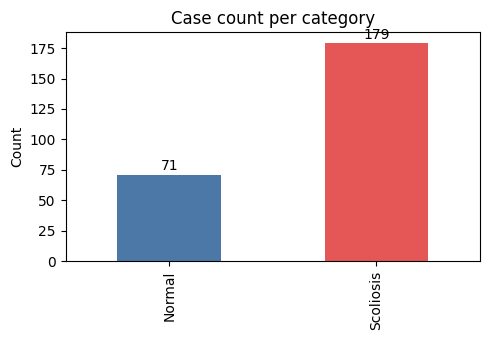

In [152]:
# ── 2.1 Category counts + class balance ratio ─────────────────────────────────
cat_counts = INDEX["category"].value_counts().reindex(["Normal", "Scoliosis"]).fillna(0).astype(int)
print("Cases per category:")
print(cat_counts.to_string())
n_normal = int(cat_counts.get("Normal", 0))
n_scol   = int(cat_counts.get("Scoliosis", 0))
ratio = (n_scol / n_normal) if n_normal else float("inf")
print(f"\nClass balance ratio (Scoliosis : Normal) = {ratio:.2f} : 1")

fig, ax = plt.subplots(figsize=(5, 3.5))
cat_counts.plot(kind="bar", ax=ax, color=["#4c78a8", "#e45756"])
ax.set_title("Case count per category")
ax.set_ylabel("Count")
ax.set_xlabel("")
for i, v in enumerate(cat_counts.values):
    ax.text(i, v + 1, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [153]:
# ── 2.2 File inventory table per category ────────────────────────────────────
inv_rows = []
for cat, sub in INDEX.groupby("category", observed=True):
    inv_rows.append({
        "category":      cat,
        "images":        sub["image_abs"].notna().sum(),
        "binary_masks":  sub["binary_mask_abs"].notna().sum(),
        "multi_masks":   sub["multi_mask_abs"].notna().sum(),
        "metrics_jsons": sub["metrics_json_abs"].notna().sum(),
        "curve_csvs":    sub["curve_csv_abs"].notna().sum(),
    })
file_inventory = pd.DataFrame(inv_rows).set_index("category")
print("File inventory per category:")
print(file_inventory.to_string())

File inventory per category:
           images  binary_masks  multi_masks  metrics_jsons  curve_csvs
category                                                               
Normal         71            71           71              0           0
Scoliosis     179           179          179            179         179


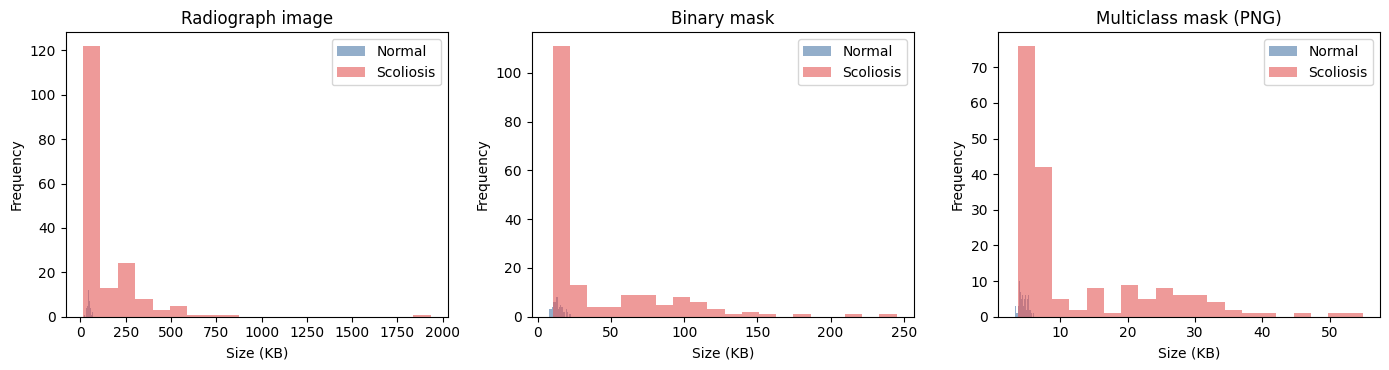

File size summary (KB):
  image        median=   46.5  min=   14.5  max=  1932.6
  binary_mask  median=   16.3  min=    7.7  max=   245.1
  multi_mask   median=    5.7  min=    3.3  max=    54.9


In [154]:
# ── 2.3 File size histograms (KB) per category ───────────────────────────────
sizes = pd.DataFrame({
    "category":    INDEX["category"],
    "image":       INDEX["image_abs"].map(file_size_kb),
    "binary_mask": INDEX["binary_mask_abs"].map(file_size_kb),
    "multi_mask":  INDEX["multi_mask_abs"].map(file_size_kb),
})

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, col, title in zip(
    axes,
    ["image", "binary_mask", "multi_mask"],
    ["Radiograph image", "Binary mask", "Multiclass mask (PNG)"],
):
    for cat, color in [("Normal", "#4c78a8"), ("Scoliosis", "#e45756")]:
        vals = sizes.loc[sizes["category"] == cat, col].dropna()
        if len(vals):
            ax.hist(vals, bins=20, alpha=0.6, label=cat, color=color)
    ax.set_title(title)
    ax.set_xlabel("Size (KB)")
    ax.set_ylabel("Frequency")
    ax.legend()
plt.tight_layout()
plt.show()

print("File size summary (KB):")
for col in ("image", "binary_mask", "multi_mask"):
    s = sizes[col].dropna()
    print(f"  {col:12s} median={s.median():7.1f}  min={s.min():7.1f}  max={s.max():8.1f}")


## 3. Image-Level Profile (T-003 / R1)

Dimensions, aspect ratio, resolution stats, channel modes.

In [183]:
# ── 3.1 Read image metadata (cheap — only header, no full pixels) ────────────
_image_meta_rows = []
for _, r in INDEX.iterrows():
    if not r["image_abs"]:
        continue
    h, w, mode = read_image_meta(r["image_abs"])
    _image_meta_rows.append({
        "patient_id": r["patient_id"],
        "category":   r["category"],
        "image":      r["image"],
        "h":          h,
        "w":          w,
        "aspect":     w / h if h else float("nan"),
        "mode":       mode,
    })
IMAGE_META = pd.DataFrame(_image_meta_rows)
print(f"Loaded metadata for {len(IMAGE_META)} images.")
IMAGE_META.sample(3)

Loaded metadata for 250 images.


,patient_id,category,image,h,w,aspect,mode
142,93,Scoliosis,S_93.jpg,1181,684,0.579170,RGB
6,7,Normal,N_7.jpg,937,220,0.234792,RGB
97,47,Scoliosis,S_47.jpg,1008,432,0.428571,RGB


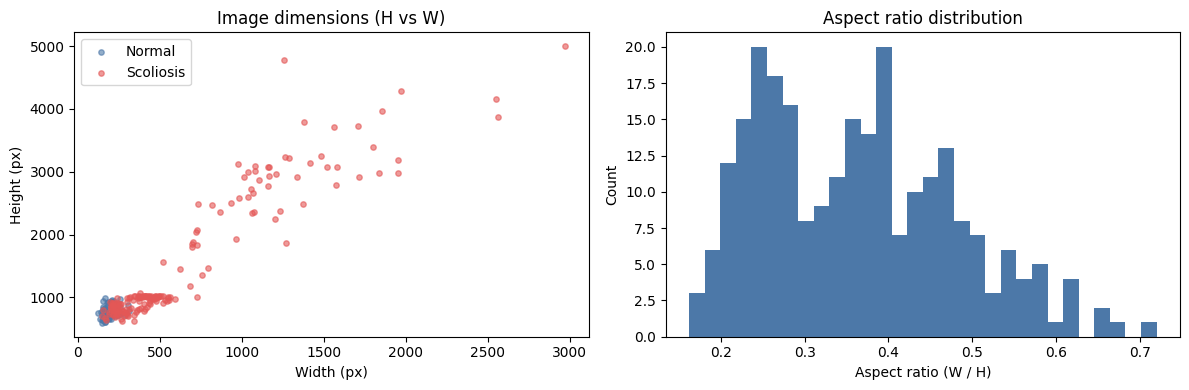

In [184]:
# ── 3.2 Dimensions scatter (H vs W), aspect ratio histogram ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cat, color in [("Normal", "#4c78a8"), ("Scoliosis", "#e45756")]:
    sub = IMAGE_META[IMAGE_META["category"] == cat]
    axes[0].scatter(sub["w"], sub["h"], alpha=0.6, label=cat, color=color, s=15)
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_title("Image dimensions (H vs W)")
axes[0].legend()

axes[1].hist(IMAGE_META["aspect"], bins=30, color="#4c78a8")
axes[1].set_xlabel("Aspect ratio (W / H)")
axes[1].set_ylabel("Count")
axes[1].set_title("Aspect ratio distribution")

plt.tight_layout()
plt.show()

In [185]:
# ── 3.3 Resolution statistics ────────────────────────────────────────────────
print("Resolution stats (pixels):")
for col in ("h", "w"):
    vals = IMAGE_META[col]
    print(f"  {col}: median={int(vals.median())}  min={int(vals.min())}  max={int(vals.max())}")
median_h = int(IMAGE_META["h"].median())
median_w = int(IMAGE_META["w"].median())
print(f"\nMedian image: {median_h}x{median_w}")
print(f"Total pixels  median: {int((IMAGE_META['h'] * IMAGE_META['w']).median()):,}")

Resolution stats (pixels):
  h: median=919  min=595  max=4999
  w: median=318  min=123  max=2972

Median image: 919x318
Total pixels  median: 274,218


Channel mode counts (rows = category, columns = PIL mode):
mode       RGB
category      
Normal      71
Scoliosis  179


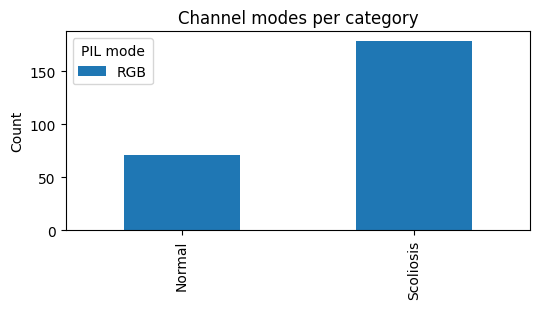

In [186]:
# ── 3.4 Channel mode count per category ──────────────────────────────────────
mode_counts = IMAGE_META.groupby(["category", "mode"], observed=True).size().unstack(fill_value=0)
print("Channel mode counts (rows = category, columns = PIL mode):")
print(mode_counts.to_string())

fig, ax = plt.subplots(figsize=(5.5, 3.2))
mode_counts.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Channel modes per category")
ax.set_ylabel("Count")
ax.set_xlabel("")
ax.legend(title="PIL mode")
plt.tight_layout()
plt.show()

## 4. Label-Level Profile (T-004 / R1)

Per-vertebra presence (IDs 1–35), target coverage histogram (IDs 6–22), spine-pixel fraction.

In [159]:
# ── 4.1 Per-case presence sets and spine fraction ────────────────────────────
_label_rows = []
for _, r in INDEX.iterrows():
    if not r["multi_mask_abs"]:
        continue
    mm = read_multi_mask(r["multi_mask_abs"])
    present = all_ids_present(mm)
    target_present = present & set(TARGET_VERTEBRA_IDS)
    out_of_range = {i for i in present if i not in TARGET_VERTEBRA_IDS}
    bin_path = r["binary_mask_abs"]
    if bin_path:
        bm = read_image(bin_path)
        if bm.ndim == 3:
            bm = bm[..., 0]
        spine_frac = float((bm > 127).mean())
    else:
        spine_frac = float("nan")
    _label_rows.append({
        "patient_id":          r["patient_id"],
        "category":            r["category"],
        "image":               r["image"],
        "all_ids_present":     sorted(present),
        "target_present_set":  sorted(target_present),
        "target_count":        len(target_present),
        "non_target_present":  sorted(out_of_range),
        "spine_pixel_frac":    spine_frac,
    })
LABEL_META = pd.DataFrame(_label_rows)
print(f"Scanned {len(LABEL_META)} multiclass masks.")
LABEL_META.head(2)

Scanned 250 multiclass masks.


,patient_id,category,image,all_ids_present,target_present_set,target_count,non_target_present,spine_pixel_frac
0,1,Normal,N_1.jpg,"[1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...","[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1...",17,"[1, 2, 3, 4]",0.209409
1,2,Normal,N_2.jpg,"[1, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...","[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1...",17,"[1, 2, 3]",0.196023


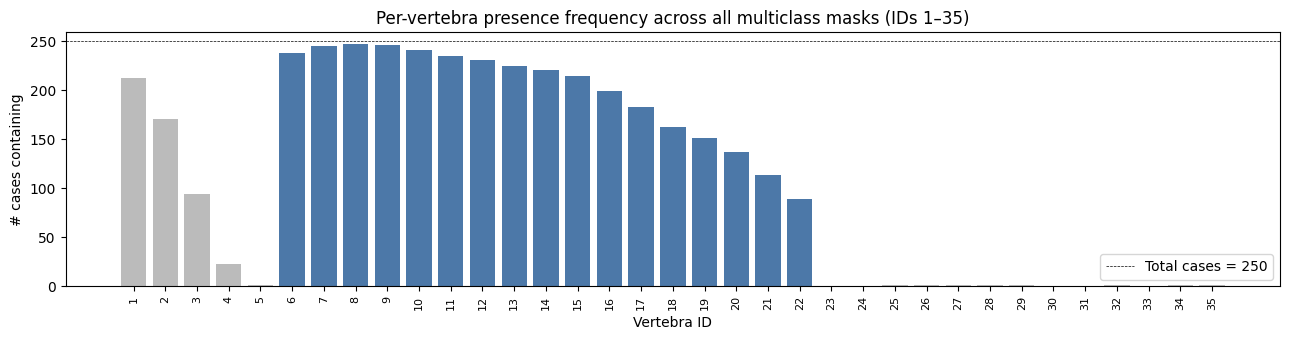

Note: blue = target IDs (6..22), grey = cervical (1..5) + auxiliary (23..35).


In [160]:
# ── 4.2 Per-vertebra presence frequency across IDs 1..35 ─────────────────────
freq = {vid: 0 for vid in ALL_VERTEBRA_IDS}
for ids in LABEL_META["all_ids_present"]:
    for vid in ids:
        if vid in freq:
            freq[vid] += 1
freq_df = pd.DataFrame(
    {
        "vertebra_id":   list(freq.keys()),
        "name":          [ALL_VERTEBRA_NAME_BY_ID[i] for i in freq.keys()],
        "present_count": list(freq.values()),
    }
)
freq_df["is_target"] = freq_df["vertebra_id"].isin(TARGET_VERTEBRA_IDS)

fig, ax = plt.subplots(figsize=(13, 3.5))
colors = ["#4c78a8" if t else "#bbbbbb" for t in freq_df["is_target"]]
ax.bar(freq_df["vertebra_id"].astype(str), freq_df["present_count"], color=colors)
ax.set_title("Per-vertebra presence frequency across all multiclass masks (IDs 1–35)")
ax.set_xlabel("Vertebra ID")
ax.set_ylabel("# cases containing")
ax.axhline(len(LABEL_META), color="black", lw=0.5, ls="--", label=f"Total cases = {len(LABEL_META)}")
ax.legend()
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()
print("Note: blue = target IDs (6..22), grey = cervical (1..5) + auxiliary (23..35).")

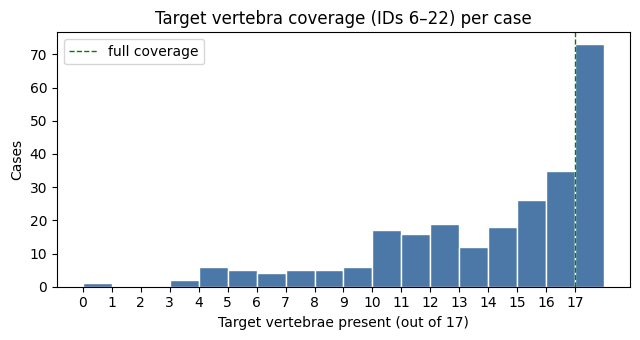

Coverage distribution:
target_count
0      1
3      2
4      6
5      5
6      4
7      5
8      5
9      6
10    17
11    16
12    19
13    12
14    18
15    26
16    35
17    73

Mean coverage: 13.52 / 17


In [161]:
# ── 4.3 Histogram of target vertebra coverage per case ───────────────────────
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(
    LABEL_META["target_count"],
    bins=range(0, TARGET_COVERAGE_FULL + 2),
    color="#4c78a8",
    edgecolor="white",
)
ax.set_xticks(range(0, TARGET_COVERAGE_FULL + 1))
ax.set_xlabel("Target vertebrae present (out of 17)")
ax.set_ylabel("Cases")
ax.set_title("Target vertebra coverage (IDs 6–22) per case")
ax.axvline(TARGET_COVERAGE_FULL, color="green", lw=1, ls="--", label="full coverage")
ax.legend()
plt.tight_layout()
plt.show()

print("Coverage distribution:")
print(LABEL_META["target_count"].value_counts().sort_index().to_string())
print(f"\nMean coverage: {LABEL_META['target_count'].mean():.2f} / {TARGET_COVERAGE_FULL}")

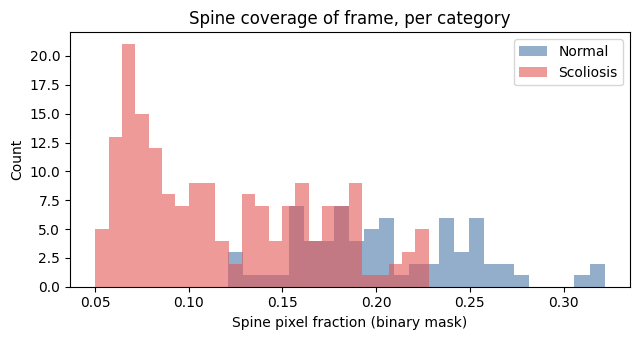

           count      mean       std       min       25%       50%       75%  \
category                                                                       
Normal      71.0  0.205307  0.045861  0.121170  0.170183  0.200099  0.239661   
Scoliosis  179.0  0.118437  0.049112  0.050235  0.073660  0.106947  0.158965   

                max  
category             
Normal     0.321836  
Scoliosis  0.228051  


In [162]:
# ── 4.4 Spine pixel fraction (binary mask) per category ──────────────────────
fig, ax = plt.subplots(figsize=(6.5, 3.5))
for cat, color in [("Normal", "#4c78a8"), ("Scoliosis", "#e45756")]:
    sub = LABEL_META[LABEL_META["category"] == cat]
    ax.hist(sub["spine_pixel_frac"].dropna(), bins=25, alpha=0.6, label=cat, color=color)
ax.set_xlabel("Spine pixel fraction (binary mask)")
ax.set_ylabel("Count")
ax.set_title("Spine coverage of frame, per category")
ax.legend()
plt.tight_layout()
plt.show()
print(LABEL_META.groupby("category", observed=True)["spine_pixel_frac"].describe())

## 5. Metrics-Level Profile (T-005 / R1)

Cobb angle distribution + severity buckets, curve length, CSVL position, apex frequency.

All metrics live in `RadiographMetrics/` and are scoliosis-only by design.

In [163]:
# ── 5.1 Build per-case metrics frame (Scoliosis only) ────────────────────────
_metrics_rows = []
for _, r in INDEX.iterrows():
    if r["category"] != "Scoliosis" or not r["metrics_json_abs"]:
        continue
    md_json = read_metrics_json(r["metrics_json_abs"])
    cobb = md_json.get("cobb_angle_deg")
    cobb_curve = md_json.get("cobb_curve_metrics", {}) or {}
    csvl = md_json.get("csvl", {}) or {}
    i_apex = cobb_curve.get("i_apex_global")
    csvl_x = csvl.get("x_px")

    curve_len = None
    if r["curve_csv_abs"]:
        try:
            curve_df = read_curve_csv(r["curve_csv_abs"])
            curve_len = len(curve_df)
        except Exception:
            curve_len = None

    _metrics_rows.append({
        "patient_id": r["patient_id"],
        "image":      r["image"],
        "cobb_deg":   cobb,
        "i_apex":     i_apex,
        "csvl_x":     csvl_x,
        "curve_len":  curve_len,
    })
METRICS = pd.DataFrame(_metrics_rows)
print(f"Loaded metrics for {len(METRICS)} scoliosis cases.")
METRICS.head(3)

Loaded metrics for 179 scoliosis cases.


,patient_id,image,cobb_deg,i_apex,csvl_x,curve_len
0,21,S_21.jpg,38.644039,192,140,719
1,22,S_22.jpg,24.874792,613,142,812
2,23,S_23.jpg,59.493486,298,266,730


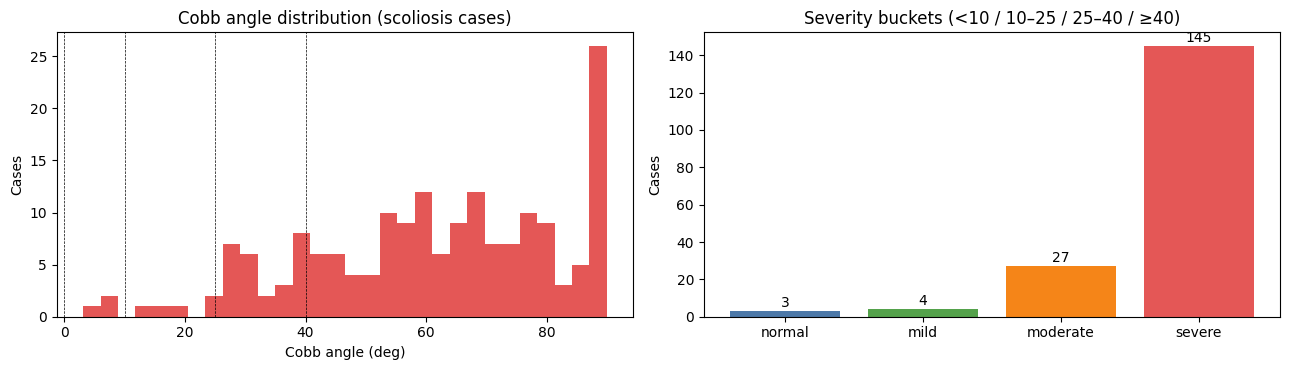

Severity counts:
severity
normal        3
mild          4
moderate     27
severe      145


In [164]:
# ── 5.2 Cobb angle histogram + severity bucket bar chart ─────────────────────
def severity_for(angle: float) -> str:
    if angle is None or pd.isna(angle):
        return "unknown"
    for name, lo, hi in SEVERITY_BUCKETS:
        if lo <= angle < hi:
            return name
    return "severe"

METRICS["severity"] = METRICS["cobb_deg"].map(severity_for)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].hist(METRICS["cobb_deg"].dropna(), bins=30, color="#e45756")
for _, lo, _ in SEVERITY_BUCKETS:
    axes[0].axvline(lo, color="black", lw=0.5, ls="--")
axes[0].set_xlabel("Cobb angle (deg)")
axes[0].set_ylabel("Cases")
axes[0].set_title("Cobb angle distribution (scoliosis cases)")

severity_order = [name for name, _, _ in SEVERITY_BUCKETS]
sev_counts = METRICS["severity"].value_counts().reindex(severity_order, fill_value=0)
axes[1].bar(sev_counts.index, sev_counts.values, color=["#4c78a8", "#54a24b", "#f58518", "#e45756"])
axes[1].set_title("Severity buckets (<10 / 10–25 / 25–40 / ≥40)")
axes[1].set_ylabel("Cases")
for i, v in enumerate(sev_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

print("Severity counts:")
print(sev_counts.to_string())

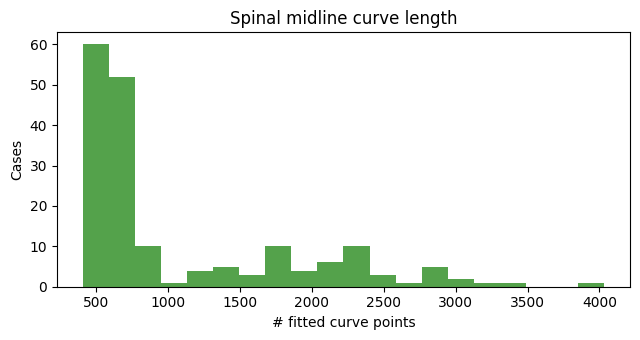

count     179.000000
mean     1092.631285
std       778.068552
min       411.000000
25%       575.500000
50%       679.000000
75%      1633.000000
max      4031.000000


In [165]:
# ── 5.3 Curve length distribution ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(METRICS["curve_len"].dropna(), bins=20, color="#54a24b")
ax.set_xlabel("# fitted curve points")
ax.set_ylabel("Cases")
ax.set_title("Spinal midline curve length")
plt.tight_layout()
plt.show()
print(METRICS["curve_len"].describe().to_string())

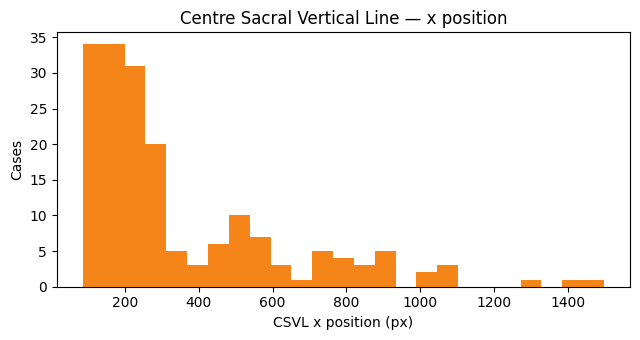

count     179.000000
mean      349.994413
std       283.575516
min        86.000000
25%       153.500000
50%       235.000000
75%       491.500000
max      1498.000000


In [166]:
# ── 5.4 CSVL x-position distribution ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(METRICS["csvl_x"].dropna(), bins=25, color="#f58518")
ax.set_xlabel("CSVL x position (px)")
ax.set_ylabel("Cases")
ax.set_title("Centre Sacral Vertical Line — x position")
plt.tight_layout()
plt.show()
print(METRICS["csvl_x"].describe().to_string())

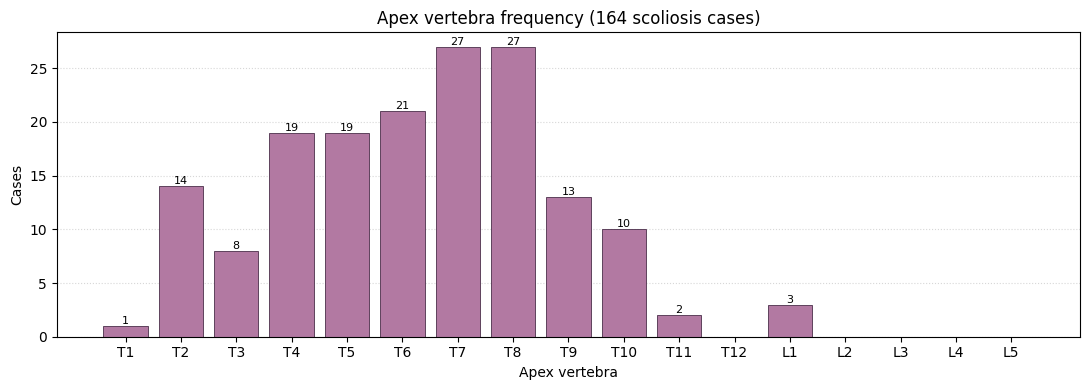

In [167]:
# ── 5.5 Apex vertebra frequency ──────────────────────────────────────────────
# `i_apex_global` is a pixel-level index into the fitted curve (0..curve_len),
# NOT a vertebra ID. Resolve it to a real vertebra label by looking up the
# multiclass mask at the curve's apex (x, y) coordinate.
apex_vid_counts: Counter = Counter()
for _, r in INDEX.iterrows():
    if r["category"] != "Scoliosis":
        continue
    if not r["metrics_json_abs"] or not r["curve_csv_abs"] or not r["multi_mask_abs"]:
        continue
    md_json = read_metrics_json(r["metrics_json_abs"])
    i_apex = (md_json.get("cobb_curve_metrics") or {}).get("i_apex_global")
    if i_apex is None:
        continue
    try:
        curve_df = read_curve_csv(r["curve_csv_abs"])
        i = int(i_apex)
        if not (0 <= i < len(curve_df)):
            continue
        x = int(round(float(curve_df.iloc[i]["x_px"])))
        y = int(round(float(curve_df.iloc[i]["y_px"])))
        mm = read_multi_mask(r["multi_mask_abs"])
        if not (0 <= y < mm.shape[0] and 0 <= x < mm.shape[1]):
            continue
        vid = int(mm[y, x])
        if vid in TARGET_VERTEBRA_IDS:
            apex_vid_counts[vid] += 1
    except Exception:
        continue

# Keep every target vertebra on the axis (even with zero cases) so the plot
# reads as an anatomical spectrum rather than a sparse scatter.
ordered_vids = list(TARGET_VERTEBRA_IDS)
counts = [apex_vid_counts.get(v, 0) for v in ordered_vids]
labels = [VERTEBRA_NAME_BY_ID[v] for v in ordered_vids]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(labels, counts, color="#b279a2", edgecolor="#4a2e4a", linewidth=0.6)
ax.set_xlabel("Apex vertebra")
ax.set_ylabel("Cases")
ax.set_title(f"Apex vertebra frequency ({sum(counts)} scoliosis cases)")
ax.tick_params(axis="x", labelrotation=0)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.set_axisbelow(True)
for i_bar, c in enumerate(counts):
    if c > 0:
        ax.text(i_bar, c, str(c), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()


## 6. Cross-Cut Sanity Correlations (T-006 / R1)

Two scatters: image resolution vs Cobb angle, and target coverage vs Cobb angle. Use to spot any obvious correlation between data quality and label severity.

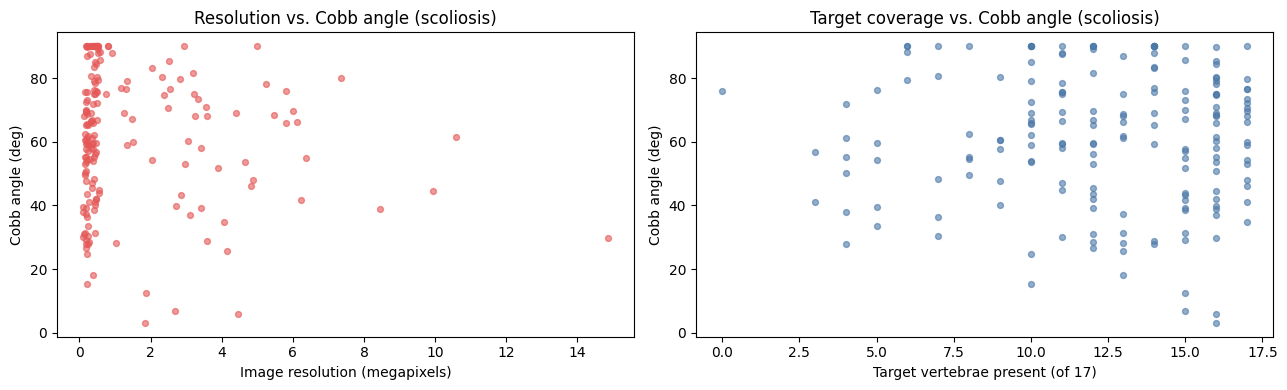

In [168]:
# Join metrics with image and label meta on (patient_id, category) — scoliosis only.
_join_meta = (
    METRICS
    .merge(IMAGE_META[["image", "h", "w"]], on="image", how="left")
    .merge(LABEL_META[["image", "target_count"]], on="image", how="left")
)
_join_meta["mp"] = _join_meta["h"] * _join_meta["w"] / 1e6  # megapixels

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(_join_meta["mp"], _join_meta["cobb_deg"], alpha=0.6, color="#e45756", s=18)
axes[0].set_xlabel("Image resolution (megapixels)")
axes[0].set_ylabel("Cobb angle (deg)")
axes[0].set_title("Resolution vs. Cobb angle (scoliosis)")

axes[1].scatter(
    _join_meta["target_count"], _join_meta["cobb_deg"], alpha=0.6, color="#4c78a8", s=18
)
axes[1].set_xlabel("Target vertebrae present (of 17)")
axes[1].set_ylabel("Cobb angle (deg)")
axes[1].set_title("Target coverage vs. Cobb angle (scoliosis)")
plt.tight_layout()
plt.show()

## 7. Inconsistency Audit (T-007 / T-008 / T-009 / T-010 — R2)

Detect 18 issue codes per case. Each detector returns a list of `(patient_id, category, issue_code, severity, details)` tuples.
Aggregation into `known_issues.csv` happens in §8.

Severity: `info` < `warn` < `fatal`. `id_out_of_range` is informational only.

In [169]:
# Shared issue-row factory and detector registry
def _issue(patient_id, category, code: str, severity: str, details: str = "") -> dict:
    return {
        "patient_id": int(patient_id) if patient_id is not None and not pd.isna(patient_id) else None,
        "category":   category,
        "issue_code": code,
        "severity":   severity,
        "details":    details,
    }

DETECTORS: list[tuple[str, Callable[[], list[dict]]]] = []  # populated below by each cell


In [170]:
# ── 7.1 (T-007) Structural integrity detectors ───────────────────────────────
# Codes covered: missing_pair_binary_mask, missing_pair_multi_mask,
#                missing_pair_metrics,  missing_pair_curve,
#                corrupt_file, index_mismatch, category_mislabeled,
#                duplicate_patient_id

def detect_structural() -> list[dict]:
    out: list[dict] = []
    seen_pid = {}  # (category, patient_id) -> first seen index
    for i, r in INDEX.iterrows():
        pid = r["patient_id"]
        cat = r["category"]
        img = r["image"]

        # Pair completeness
        if not r["binary_mask_abs"] or not Path(r["binary_mask_abs"]).exists():
            out.append(_issue(pid, cat, "missing_pair_binary_mask", "fatal",
                              f"image={img}"))
        if not r["multi_mask_abs"] or not Path(r["multi_mask_abs"]).exists():
            out.append(_issue(pid, cat, "missing_pair_multi_mask", "fatal",
                              f"image={img}"))
        # Metrics + curve only required for Scoliosis category
        if cat == "Scoliosis":
            if not r["metrics_json_abs"] or not Path(r["metrics_json_abs"]).exists():
                out.append(_issue(pid, cat, "missing_pair_metrics", "warn",
                                  f"image={img}"))
            if not r["curve_csv_abs"] or not Path(r["curve_csv_abs"]).exists():
                out.append(_issue(pid, cat, "missing_pair_curve", "warn",
                                  f"image={img}"))

        # corrupt_file: try to open the image header
        try:
            if r["image_abs"]:
                read_image_meta(r["image_abs"])
        except Exception as e:
            out.append(_issue(pid, cat, "corrupt_file", "fatal", f"image: {e}"))

        # index_mismatch: image filename prefix must match category
        stem = Path(img).stem if isinstance(img, str) else ""
        prefix = stem.split("_", 1)[0] if "_" in stem else ""
        expected = "S" if cat == "Scoliosis" else "N" if cat == "Normal" else None
        if expected and prefix != expected:
            out.append(_issue(pid, cat, "index_mismatch", "fatal",
                              f"image stem prefix '{prefix}' != expected '{expected}'"))

        # category_mislabeled: scoliosis case w/ no metrics + cobb=0 → mislabel? we
        # only flag the easy direction here: a Normal case that does NOT match its
        # 'N_' filename pattern (handled by index_mismatch). Stricter checks live in
        # T-010 metrics detector.

        # duplicate_patient_id (within category)
        key = (cat, int(pid)) if pid is not None and not pd.isna(pid) else None
        if key is not None:
            if key in seen_pid:
                out.append(_issue(pid, cat, "duplicate_patient_id", "fatal",
                                  f"first seen at index {seen_pid[key]}"))
            else:
                seen_pid[key] = i
    return out

DETECTORS.append(("structural", detect_structural))
print(f"Registered structural detector ({len(DETECTORS)} total)")

Registered structural detector (1 total)


In [171]:
# ── 7.2 (T-008) Spatial detectors ────────────────────────────────────────────
# Codes: dim_mismatch, resolution_outlier, channel_inconsistency

def detect_spatial() -> list[dict]:
    out: list[dict] = []
    # Pre-compute dataset median + std for resolution outlier rule
    hs = IMAGE_META["h"].astype(float)
    ws = IMAGE_META["w"].astype(float)
    h_med, h_std = hs.median(), hs.std()
    w_med, w_std = ws.median(), ws.std()

    img_meta_by_image = {row["image"]: row for _, row in IMAGE_META.iterrows()}

    for _, r in INDEX.iterrows():
        pid = r["patient_id"]
        cat = r["category"]
        img = r["image"]
        meta = img_meta_by_image.get(img)
        if meta is None:
            continue
        ih, iw, imode = int(meta["h"]), int(meta["w"]), meta["mode"]

        # dim_mismatch: image vs binary mask vs multi mask
        for label_path, label_name in [
            (r["binary_mask_abs"], "binary_mask"),
            (r["multi_mask_abs"], "multi_mask"),
        ]:
            if not label_path or not Path(label_path).exists():
                continue
            try:
                lh, lw, _ = read_image_meta(label_path)
            except Exception:
                continue
            if (lh, lw) != (ih, iw):
                out.append(_issue(pid, cat, "dim_mismatch", "fatal",
                                  f"{label_name}={lh}x{lw} vs image={ih}x{iw}"))

        # resolution_outlier: > 2 std from median (height OR width)
        if abs(ih - h_med) > 2 * h_std or abs(iw - w_med) > 2 * w_std:
            out.append(_issue(pid, cat, "resolution_outlier", "warn",
                              f"image={ih}x{iw}, median={int(h_med)}x{int(w_med)} std=({h_std:.0f},{w_std:.0f})"))

        # channel_inconsistency: anything other than the dataset's dominant mode
        # (computed once below)
        if imode not in DOMINANT_IMAGE_MODES:
            out.append(_issue(pid, cat, "channel_inconsistency", "warn",
                              f"mode={imode}, expected one of {sorted(DOMINANT_IMAGE_MODES)}"))
    return out

# Dominant modes = those that cover ≥ 95% of cases
_mode_pct = IMAGE_META["mode"].value_counts(normalize=True)
DOMINANT_IMAGE_MODES = set(_mode_pct[_mode_pct >= 0.05].index.tolist()) or set(_mode_pct.index[:1])
print(f"Dominant image modes (≥5% of cases): {sorted(DOMINANT_IMAGE_MODES)}")

DETECTORS.append(("spatial", detect_spatial))
print(f"Registered spatial detector ({len(DETECTORS)} total)")

Dominant image modes (≥5% of cases): ['RGB']
Registered spatial detector (2 total)


In [172]:
# ── 7.3 (T-009) Label-content detectors ──────────────────────────────────────
# Codes: id_out_of_range (info), target_coverage_low (warn), empty_mask (fatal)
# Coverage checks evaluated ONLY on target IDs (6..22).

def detect_label_content() -> list[dict]:
    out: list[dict] = []
    label_by_image = {row["image"]: row for _, row in LABEL_META.iterrows()}
    for _, r in INDEX.iterrows():
        pid = r["patient_id"]
        cat = r["category"]
        img = r["image"]
        lm = label_by_image.get(img)
        if lm is None:
            continue
        target_count = int(lm["target_count"])
        all_present = set(lm["all_ids_present"])
        non_target = set(lm["non_target_present"])

        # id_out_of_range: any ID not in TARGET set is informational
        if non_target:
            out.append(_issue(pid, cat, "id_out_of_range", "info",
                              f"non_target_ids={sorted(non_target)}"))

        # target_coverage_low: <14 of 17
        if target_count < 14:
            out.append(_issue(pid, cat, "target_coverage_low", "warn",
                              f"target_count={target_count} (<14)"))

        # empty_mask: zero target IDs present
        if target_count == 0:
            out.append(_issue(pid, cat, "empty_mask", "fatal",
                              "no target vertebra IDs (6..22) found in mask"))
    return out

DETECTORS.append(("label_content", detect_label_content))
print(f"Registered label-content detector ({len(DETECTORS)} total)")

Registered label-content detector (3 total)


In [173]:
# ── 7.4 (T-010) Metrics & curve detectors ────────────────────────────────────
# Codes: cobb_angle_outlier (<5 or >120),
#        missing_metadata_scoliosis,
#        curve_invalid,
#        csvl_apex_out_of_range,
#        category_mislabeled (cobb=0 on scoliosis case)

def detect_metrics_curve() -> list[dict]:
    out: list[dict] = []
    for _, r in INDEX.iterrows():
        pid = r["patient_id"]
        cat = r["category"]
        img = r["image"]
        if cat != "Scoliosis":
            continue
        mp = r["metrics_json_abs"]
        if not mp or not Path(mp).exists():
            out.append(_issue(pid, cat, "missing_metadata_scoliosis", "warn",
                              "no metrics_*.json"))
            continue
        try:
            md_json = read_metrics_json(mp)
        except Exception as e:
            out.append(_issue(pid, cat, "missing_metadata_scoliosis", "warn",
                              f"unparsable metrics: {e}"))
            continue

        cobb = md_json.get("cobb_angle_deg")
        if cobb is None:
            out.append(_issue(pid, cat, "missing_metadata_scoliosis", "warn",
                              "metrics missing cobb_angle_deg"))
        else:
            try:
                cobb_f = float(cobb)
            except (TypeError, ValueError):
                cobb_f = None
            if cobb_f is not None:
                if cobb_f < 5.0 or cobb_f > 120.0:
                    out.append(_issue(pid, cat, "cobb_angle_outlier", "warn",
                                      f"cobb={cobb_f:.1f}"))
                if cobb_f == 0.0:
                    out.append(_issue(pid, cat, "category_mislabeled", "fatal",
                                      "scoliosis case with cobb_angle_deg == 0"))

        cobb_curve = md_json.get("cobb_curve_metrics", {}) or {}
        i_apex = cobb_curve.get("i_apex_global")
        i_inf_above = cobb_curve.get("i_inf_above")
        i_inf_below = cobb_curve.get("i_inf_below")
        csvl = (md_json.get("csvl") or {}).get("x_px")

        # csvl_apex_out_of_range: apex/csvl outside the curve length
        cv = r["curve_csv_abs"]
        curve_n = None
        if cv and Path(cv).exists():
            try:
                curve_df = read_curve_csv(cv)
                curve_n = len(curve_df)
                if curve_n < 5:
                    out.append(_issue(pid, cat, "curve_invalid", "warn",
                                      f"curve has only {curve_n} points"))
                else:
                    cols_lower = {c.lower(): c for c in curve_df.columns}
                    if not any(c in cols_lower for c in ("x_px", "x")):
                        out.append(_issue(pid, cat, "curve_invalid", "warn",
                                          f"curve missing x column: {list(curve_df.columns)}"))
            except Exception as e:
                out.append(_issue(pid, cat, "curve_invalid", "warn", f"unparsable curve: {e}"))

        if curve_n is not None:
            for name, idx in [("i_apex", i_apex),
                              ("i_inf_above", i_inf_above),
                              ("i_inf_below", i_inf_below)]:
                if idx is None:
                    continue
                try:
                    idx_i = int(idx)
                except (TypeError, ValueError):
                    continue
                if idx_i < 0 or idx_i >= curve_n:
                    out.append(_issue(pid, cat, "csvl_apex_out_of_range", "warn",
                                      f"{name}={idx_i} outside [0,{curve_n})"))
    return out

DETECTORS.append(("metrics_curve", detect_metrics_curve))
print(f"Registered metrics/curve detector ({len(DETECTORS)} total)")

Registered metrics/curve detector (4 total)


## 8. Aggregate Detectors → `known_issues.csv` (T-011 / R2)

Run all registered detectors, concatenate, write to `data/processed/audit/known_issues.csv`, and print a per-issue summary table.

In [174]:
# ── 8.1 Run all detectors and build the audit frame ──────────────────────────
def run_detectors() -> pd.DataFrame:
    random.seed(SEED)
    np.random.seed(SEED)
    rows: list[dict] = []
    for name, fn in DETECTORS:
        out = fn()
        print(f"  detector {name:14s} → {len(out):4d} issues")
        rows.extend(out)
    return pd.DataFrame(
        rows,
        columns=["patient_id", "category", "issue_code", "severity", "details"],
    ).sort_values(
        ["patient_id", "category", "issue_code", "severity", "details"],
        kind="mergesort",
    ).reset_index(drop=True)

ISSUES = run_detectors()
print(f"\nTotal issue rows: {len(ISSUES)}")


  detector structural     →    0 issues
  detector spatial        →   34 issues
  detector label_content  →  313 issues
  detector metrics_curve  →    1 issues

Total issue rows: 348


In [175]:
# ── 8.2 Write known_issues.csv (deterministic, no index column) ──────────────
ISSUES.to_csv(KNOWN_ISSUES_CSV, index=False, lineterminator="\n")
print(f"Wrote {KNOWN_ISSUES_CSV}  ({len(ISSUES)} rows)")


Wrote /home/ortiz/scoliosis/data/processed/audit/known_issues.csv  (348 rows)


In [176]:
# ── 8.3 Per-issue-code summary table ─────────────────────────────────────────
summary = (
    ISSUES.groupby(["issue_code", "severity"], observed=True)
          .size()
          .unstack(fill_value=0)
          .reindex(list(EXPECTED_ISSUE_CODES), fill_value=0)
)
for col in ("info", "warn", "fatal"):
    if col not in summary.columns:
        summary[col] = 0
summary = summary[["info", "warn", "fatal"]]
print("Issue-code summary (rows = code, columns = severity):")
print(summary.to_string())


Issue-code summary (rows = code, columns = severity):
severity                    info  warn  fatal
issue_code                                   
missing_pair_binary_mask       0     0      0
missing_pair_multi_mask        0     0      0
missing_pair_metrics           0     0      0
missing_pair_curve             0     0      0
corrupt_file                   0     0      0
index_mismatch                 0     0      0
category_mislabeled            0     0      0
duplicate_patient_id           0     0      0
dim_mismatch                   0     0      0
resolution_outlier             0    34      0
channel_inconsistency          0     0      0
id_out_of_range              214     0      0
target_coverage_low            0    98      0
empty_mask                     0     0      1
cobb_angle_outlier             0     1      0
missing_metadata_scoliosis     0     0      0
curve_invalid                  0     0      0
csvl_apex_out_of_range         0     0      0


## 9. Clean Manifest `clean_index.csv` (T-012 / R3)

Build `clean_index.csv` with one row per case in the original `dataset_index.csv`, plus a `status ∈ {ok, warn, excluded}` column derived from `known_issues.csv`. No rows are dropped.

In [177]:
# ── 9.1 Per-case feature aggregation ─────────────────────────────────────────
def build_clean_index(issues: pd.DataFrame) -> pd.DataFrame:
    label_by_image   = {r["image"]: r for _, r in LABEL_META.iterrows()}
    meta_by_image    = {r["image"]: r for _, r in IMAGE_META.iterrows()}
    metrics_by_image = {r["image"]: r for _, r in METRICS.iterrows()} if len(METRICS) else {}

    codes_by_key: dict[tuple[int, str], list[str]] = {}
    for _, ir in issues.iterrows():
        if ir["patient_id"] is None or pd.isna(ir["patient_id"]):
            continue
        key = (int(ir["patient_id"]), ir["category"])
        codes_by_key.setdefault(key, []).append(ir["issue_code"])

    def classify(target_count: int, codes: list[str]) -> str:
        code_set = set(codes)
        if code_set & EXCLUDE_TRIGGER_CODES or target_count <= 13:
            return "excluded"
        if target_count in (14, 15, 16) or code_set & WARN_TRIGGER_CODES:
            return "warn"
        if target_count == 17:
            return "ok"
        return "warn"  # defensive fallback

    rows = []
    for _, r in INDEX.iterrows():
        img = r["image"]
        pid = int(r["patient_id"]) if r["patient_id"] is not None and not pd.isna(r["patient_id"]) else None
        cat = r["category"]
        meta = meta_by_image.get(img)
        lab  = label_by_image.get(img)
        mtr  = metrics_by_image.get(img)
        target_present = sorted(lab["target_present_set"]) if lab is not None else []
        target_count = len(target_present)
        target_names = ",".join(VERTEBRA_NAME_BY_ID[v] for v in target_present)
        codes = codes_by_key.get((pid, cat), []) if pid is not None else []
        rows.append({
            "patient_id":               pid,
            "category":                 cat,
            "image_path":               r["image_abs"],
            "binary_mask_path":         r["binary_mask_abs"],
            "multiclass_mask_path":     r["multi_mask_abs"],
            "metrics_json_path":        r["metrics_json_abs"],
            "curve_csv_path":           r["curve_csv_abs"],
            "image_h":                  int(meta["h"]) if meta is not None else None,
            "image_w":                  int(meta["w"]) if meta is not None else None,
            "cobb_angle_deg":           float(mtr["cobb_deg"]) if (mtr is not None and pd.notna(mtr.get("cobb_deg"))) else None,
            "target_vertebrae_count":   target_count,
            "target_vertebrae_present": target_names,
            "status":                   classify(target_count, codes),
            "issues":                   ";".join(sorted(set(codes))),
        })
    return pd.DataFrame(
        rows,
        columns=[
            "patient_id", "category", "image_path", "binary_mask_path", "multiclass_mask_path",
            "metrics_json_path", "curve_csv_path", "image_h", "image_w", "cobb_angle_deg",
            "target_vertebrae_count", "target_vertebrae_present", "status", "issues",
        ],
    ).sort_values(["category", "patient_id"], kind="mergesort").reset_index(drop=True)

CLEAN_INDEX = build_clean_index(ISSUES)
assert len(CLEAN_INDEX) == len(INDEX), "row count must equal raw dataset_index.csv"
print(f"Built clean index: {len(CLEAN_INDEX)} rows (raw index = {len(INDEX)})")
CLEAN_INDEX.head(3)


Built clean index: 250 rows (raw index = 250)


,patient_id,category,image_path,binary_mask_path,multiclass_mask_path,metrics_json_path,curve_csv_path,image_h,image_w,cobb_angle_deg,target_vertebrae_count,target_vertebrae_present,status,issues
0,1,Normal,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,None,None,971,259,NaN,17,"T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,L1,L2,L...",ok,id_out_of_range
1,2,Normal,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,None,None,828,218,NaN,17,"T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,L1,L2,L...",ok,id_out_of_range
2,3,Normal,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,/home/ortiz/scoliosis/data/raw/MaIA_Scoliosis_...,None,None,939,206,NaN,17,"T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,L1,L2,L...",ok,id_out_of_range


In [178]:
# ── 9.2 Write clean_index.csv (deterministic) ────────────────────────────────
CLEAN_INDEX.to_csv(CLEAN_INDEX_CSV, index=False, lineterminator="\n")
print(f"Wrote {CLEAN_INDEX_CSV}  ({len(CLEAN_INDEX)} rows)")


Wrote /home/ortiz/scoliosis/data/processed/audit/clean_index.csv  (250 rows)


In [179]:
# ── 9.3 Status summary ───────────────────────────────────────────────────────
status_counts = CLEAN_INDEX["status"].value_counts().reindex(["ok", "warn", "excluded"], fill_value=0)
print("Cases per status:")
print(status_counts.to_string())
print(f"\nTotal: {int(status_counts.sum())} (must equal raw index = {len(INDEX)})")


Cases per status:
status
ok          65
warn        87
excluded    98

Total: 250 (must equal raw index = 250)


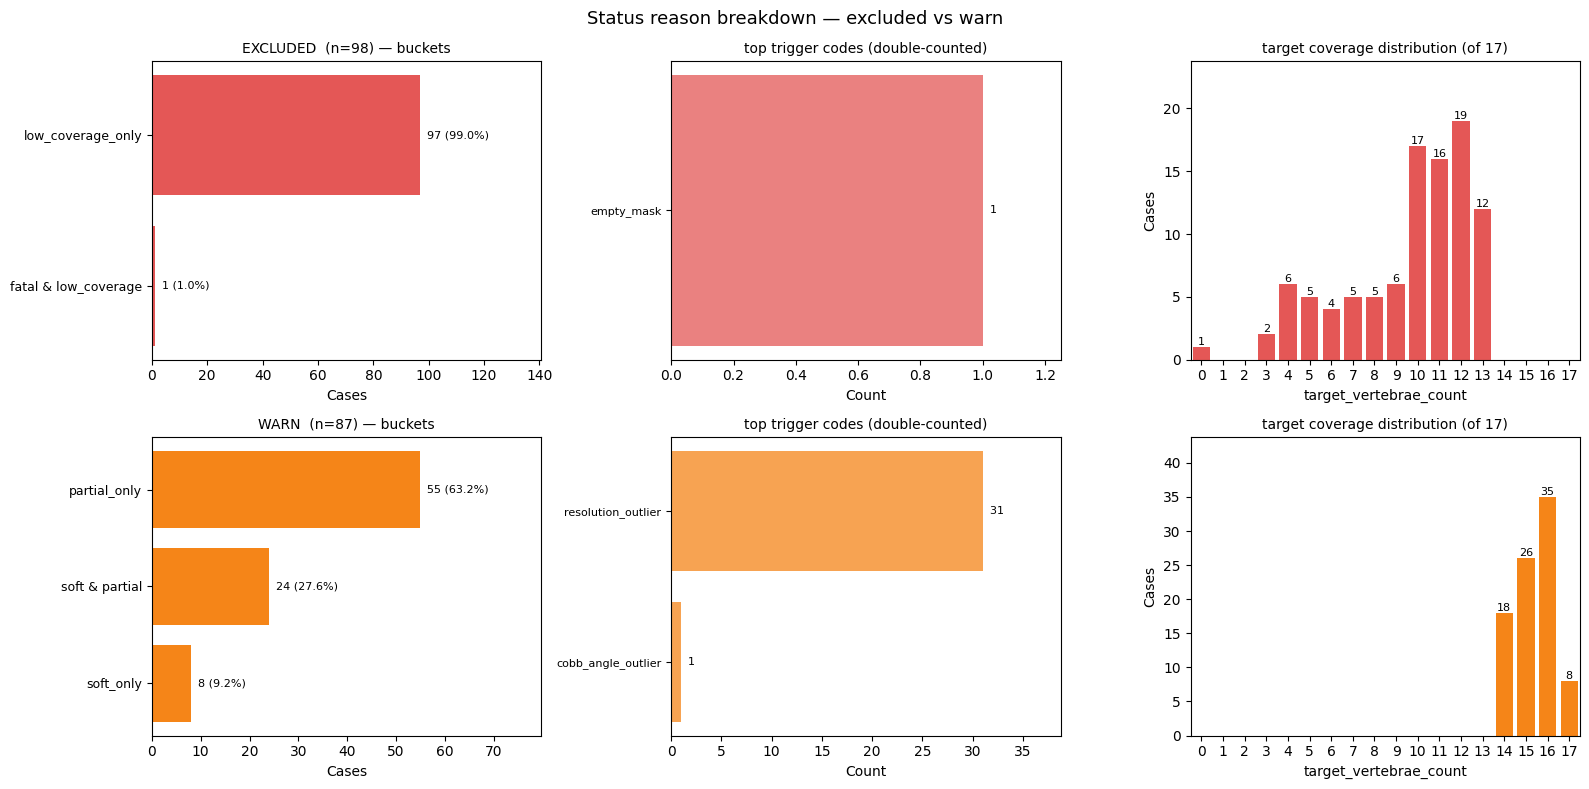

In [180]:
# ── 9.4 Status reason breakdown (graphical) ─────────────────────────────────
def _row_codes(row) -> set[str]:
    return {c for c in str(row["issues"]).split(";") if c}

def _bucket(status: str, codes: set[str], tc: int) -> str:
    if status == "excluded":
        has_fatal = bool(codes & EXCLUDE_TRIGGER_CODES)
        low_cov = tc <= 13
        if has_fatal and low_cov:
            return "fatal & low_coverage"
        if has_fatal:
            return "fatal_only"
        if low_cov:
            return "low_coverage_only"
        raise AssertionError(f"excluded row with no reason: codes={codes}, tc={tc}")
    if status == "warn":
        has_soft = bool(codes & WARN_TRIGGER_CODES)
        partial = tc in (14, 15, 16)
        if has_soft and partial:
            return "soft & partial"
        if has_soft:
            return "soft_only"
        if partial:
            return "partial_only"
        raise AssertionError(f"warn row with no reason: codes={codes}, tc={tc}")
    return "n/a"

def _aggregate(status: str, trigger_codes: frozenset[str]):
    sub = CLEAN_INDEX[CLEAN_INDEX["status"] == status]
    buckets: Counter[str] = Counter()
    code_counter: Counter[str] = Counter()
    for _, r in sub.iterrows():
        codes = _row_codes(r)
        tc = int(r["target_vertebrae_count"])
        buckets[_bucket(status, codes, tc)] += 1
        for c in codes & trigger_codes:
            code_counter[c] += 1
    cov = sub["target_vertebrae_count"].value_counts().sort_index()
    return len(sub), buckets, code_counter, cov

def _empty(ax, msg: str = "(none)") -> None:
    ax.text(0.5, 0.5, msg, ha="center", va="center",
            transform=ax.transAxes, color="#999", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

def _plot_row(axes, status: str, trigger_codes: frozenset[str], color: str) -> None:
    n, buckets, code_counter, cov = _aggregate(status, trigger_codes)
    ax_b, ax_c, ax_cov = axes
    tag = f"{status.upper()}  (n={n})"

    # (1) Bucket histogram — horizontal bars with count + pct
    if buckets:
        items = buckets.most_common()
        names = [k for k, _ in items]
        vals  = [v for _, v in items]
        ypos  = list(range(len(names)))[::-1]
        ax_b.barh(ypos, vals, color=color)
        ax_b.set_yticks(ypos)
        ax_b.set_yticklabels(names, fontsize=9)
        for y, v in zip(ypos, vals):
            ax_b.text(v, y, f"  {v} ({100.0 * v / n:.1f}%)",
                      va="center", fontsize=8)
        ax_b.set_xlim(0, max(vals) * 1.45)
    else:
        _empty(ax_b)
    ax_b.set_title(f"{tag} — buckets", fontsize=10)
    ax_b.set_xlabel("Cases")

    # (2) Top trigger codes — horizontal bars (row may contribute multiple)
    if code_counter:
        items = code_counter.most_common()
        names = [k for k, _ in items]
        vals  = [v for _, v in items]
        ypos  = list(range(len(names)))[::-1]
        ax_c.barh(ypos, vals, color=color, alpha=0.75)
        ax_c.set_yticks(ypos)
        ax_c.set_yticklabels(names, fontsize=8)
        for y, v in zip(ypos, vals):
            ax_c.text(v, y, f"  {v}", va="center", fontsize=8)
        ax_c.set_xlim(0, max(vals) * 1.25)
    else:
        _empty(ax_c, "(no trigger codes)")
    ax_c.set_title("top trigger codes (double-counted)", fontsize=10)
    ax_c.set_xlabel("Count")

    # (3) Coverage distribution across 0..17
    if len(cov):
        xs = cov.index.astype(int).to_numpy()
        ys = cov.values
        ax_cov.bar(xs, ys, color=color)
        for x, v in zip(xs, ys):
            ax_cov.text(x, v, str(int(v)), ha="center", va="bottom", fontsize=8)
        ax_cov.set_ylim(0, max(ys) * 1.25)
        ax_cov.set_xticks(list(range(0, 18)))
        ax_cov.set_xlim(-0.5, 17.5)
    else:
        _empty(ax_cov)
    ax_cov.set_title("target coverage distribution (of 17)", fontsize=10)
    ax_cov.set_xlabel("target_vertebrae_count")
    ax_cov.set_ylabel("Cases")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
_plot_row(axes[0], "excluded", EXCLUDE_TRIGGER_CODES, "#e45756")
_plot_row(axes[1], "warn",     WARN_TRIGGER_CODES,    "#f58518")
fig.suptitle("Status reason breakdown — excluded vs warn", fontsize=13)
plt.tight_layout()
plt.show()


## 10. Reproducibility Verification (T-013 / R4)

Re-runs the audit pipeline a second time **in-kernel** with the same seed and confirms that `clean_index.csv` and `known_issues.csv` are byte-identical to the first run.

Why in-kernel: a real second cold run requires Restart-and-Run-All, which the user must perform manually. This cell verifies the *deterministic* property by comparing two outputs of the same logic on the same input.

In [181]:
# ── 10.1 In-memory rerun + byte-hash comparison ──────────────────────────────
def _df_hash(df: pd.DataFrame) -> str:
    return hashlib.sha256(df.to_csv(index=False, lineterminator="\n").encode()).hexdigest()

ISSUES2 = run_detectors()
CLEAN2 = build_clean_index(ISSUES2)

h1_issues, h2_issues = _df_hash(ISSUES), _df_hash(ISSUES2)
h1_clean,  h2_clean  = _df_hash(CLEAN_INDEX), _df_hash(CLEAN2)

print(f"known_issues  first={h1_issues}")
print(f"              repro={h2_issues}")
print(f"clean_index   first={h1_clean}")
print(f"              repro={h2_clean}")

assert h1_issues == h2_issues, "known_issues.csv NOT byte-identical across reruns"
assert h1_clean  == h2_clean,  "clean_index.csv  NOT byte-identical across reruns"
print("\n✓ Reproducibility verified: in-kernel rerun produces byte-identical outputs.")
print("  For a full Restart-and-Run-All check: kernel → Restart → Run All from a fresh kernel.")


  detector structural     →    0 issues
  detector spatial        →   34 issues
  detector label_content  →  313 issues
  detector metrics_curve  →    1 issues
known_issues  first=811bd041073292b0075fcda00adf8f8bdeee8e6f52a82bdf06ce48848992ad21
              repro=811bd041073292b0075fcda00adf8f8bdeee8e6f52a82bdf06ce48848992ad21
clean_index   first=22effa3be4b19ee75cfde398726240477a4bc7017718b6b6d48b813328919359
              repro=22effa3be4b19ee75cfde398726240477a4bc7017718b6b6d48b813328919359

✓ Reproducibility verified: in-kernel rerun produces byte-identical outputs.
  For a full Restart-and-Run-All check: kernel → Restart → Run All from a fresh kernel.


In [182]:
# ── 10.2 Final summary ───────────────────────────────────────────────────────
print("=" * 60)
print("Dataset Audit Complete")
print("=" * 60)
print(f"Raw index rows:         {len(INDEX)}")
print(f"Issue rows:             {len(ISSUES)}")
print(f"Status counts:          {dict(status_counts)}")
print(f"Outputs:")
print(f"  {KNOWN_ISSUES_CSV.relative_to(REPO_ROOT)}")
print(f"  {CLEAN_INDEX_CSV.relative_to(REPO_ROOT)}")
print(f"Seed:                   {SEED}")

Dataset Audit Complete
Raw index rows:         250
Issue rows:             348
Status counts:          {'ok': np.int64(65), 'warn': np.int64(87), 'excluded': np.int64(98)}
Outputs:
  data/processed/audit/known_issues.csv
  data/processed/audit/clean_index.csv
Seed:                   42
